In [1]:
import sksurv #scikit-survival
import pandas as pd
import numpy as np
import sys
import os


sys.path.append(os.path.abspath("../../"))
from src.utils.ConvertTextToCsv import TextToCsv
from src.utils.Preprocessing import Preprocessor
from src.utils.plots import Plots
%load_ext autoreload
%autoreload 2

In [2]:
pp = Preprocessor()
plots = Plots()
df_clinical_data = pd.read_csv("../../data/raw/brca_tcga_pub2015_clinical_data.tsv", sep='\t')
df_clinical_keep = pp.clean_columns_dataset(df_clinical_data)

    

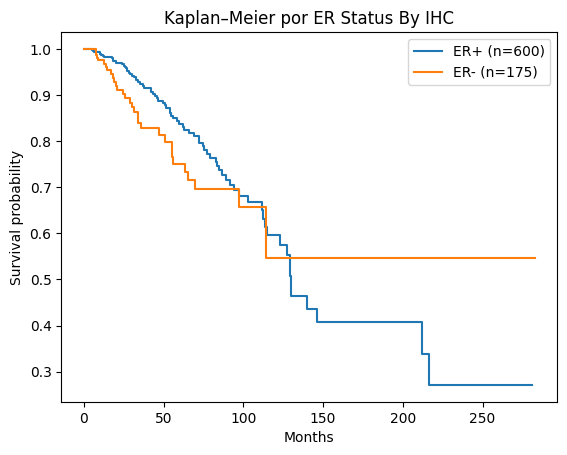

Log-rank: chi2=1.638, p=0.2007


In [3]:

km_df = plots.plot_kaplan_meier_binary(df_clinical_keep, time_col="Overall Survival (Months)", status_col="Overall Survival Status",marker_col="ER Status By IHC")

In [4]:
list_df = pp.total_type_len_type_cancer(df_clinical_keep)
df_clinical_keep["Tumor-Cancer"] = list_df
df_mRNA_transformed = TextToCsv("../../data/raw/data_mrna_seq_v2_rsem.txt")



Luminal A: 330 - Total(%): 0.40
Luminal B: 81 - Total(%):0.10
HER2-enriched: 23 - Total(%):0.03
TNBC: 85 - Total(%)0.10 
UNK: 298 - Total(%) 0.36
Shape of the CSV: (20440, 819)


In [ ]:
clean_df = pp.elimnation_zeros(df_mRNA_transformed, "Hugo_Symbol")
ESR1 = clean_df[clean_df["Hugo_Symbol"] == "ESR1"]
AURKA = clean_df[clean_df["Hugo_Symbol"] == "AURKA"]


pacientes = ESR1.iloc[:, 2:]

expr = pacientes.iloc[0]

threshold = np.median(expr)

"""

lower_bound = [single_value.index for values in expr.values for single_value 
                   in values if single_value < threshold]
upper_bound = [single_value.index for values in expr for single_value
                   in values if single_value >= threshold]
"""
low_bound = list()
upper_bound = list()

for patient_id ,value in expr.items():
   if value < threshold:
      low_bound.append(patient_id)
   else:
      upper_bound.append(patient_id)


print(low_bound)
print(upper_bound)

Max of zeros per row in the dataset: 4575
Avg of zeros per row in the dataset: 2911.273838630807
Median of zeros per row in the dataset: 2866.5
Min of zeros per row in the dataset: 0
After the 0 elimination: 454
['TCGA-A1-A0SE-01', 'TCGA-A1-A0SI-01', 'TCGA-A1-A0SJ-01', 'TCGA-A1-A0SK-01', 'TCGA-A1-A0SM-01', 'TCGA-A1-A0SP-01', 'TCGA-A2-A04P-01', 'TCGA-A2-A04Q-01', 'TCGA-A2-A04T-01', 'TCGA-A2-A0CK-01', 'TCGA-A2-A0CL-01', 'TCGA-A2-A0CO-01', 'TCGA-A2-A0CR-01', 'TCGA-A2-A0EP-01', 'TCGA-A2-A0ST-01', 'TCGA-A2-A0SV-01', 'TCGA-A2-A0SX-01', 'TCGA-A2-A0T1-01', 'TCGA-A2-A0T6-01', 'TCGA-A2-A0T7-01', 'TCGA-A2-A0YL-01', 'TCGA-A2-A0YM-01', 'TCGA-A2-A1G0-01', 'TCGA-A2-A1G1-01', 'TCGA-A2-A1G6-01', 'TCGA-A2-A25A-01', 'TCGA-A2-A25C-01', 'TCGA-A2-A25F-01', 'TCGA-A2-A3XS-01', 'TCGA-A2-A3XT-01', 'TCGA-A2-A3XW-01', 'TCGA-A2-A3XX-01', 'TCGA-A2-A3XY-01', 'TCGA-A2-A3XZ-01', 'TCGA-A2-A3Y0-01', 'TCGA-A2-A4RW-01', 'TCGA-A2-A4RX-01', 'TCGA-A2-A4RY-01', 'TCGA-A7-A0CE-01', 'TCGA-A7-A0DA-01', 'TCGA-A7-A26F-01', 'TCGA-A7

In [ ]:

"""
for i, row in enumerate(ESR1):
    print(row)
    """
treshold_AURKA = np.median(AURKA.iloc[:, 2:])
print(treshold_AURKA)

AURKA.iloc[:, 2:].values
"""
low_bound = list()
big_bound = list()
for values in AURKA.iloc[:, 2:].values:
    for single_value in values:
        if single_value >= treshold_AURKA:
            big_bound.append(single_value.item())
        else: 
            low_bound.append(single_value.item())
"""            
lower_bound = [single_value.item() for values in AURKA.iloc[:, 2:].values 
               for single_value in values if single_value <= treshold_AURKA]

print(lower_bound)

419.1242
[103.1648, 343.7267, 400.1645, 231.3379, 147.7114, 341.5404, 141.4422, 339.3767, 377.6847, 217.3737, 81.8799, 83.1099, 244.0375, 128.4138, 256.5759, 108.8804, 101.2413, 194.6023, 168.0936, 156.7432, 184.3855, 93.2479, 286.0238, 382.807, 103.0818, 129.1594, 216.0999, 167.5958, 215.5558, 102.7811, 218.3941, 171.6724, 415.5154, 109.1234, 135.4551, 253.7039, 176.5198, 184.5263, 126.5615, 69.3796, 123.7985, 191.3496, 405.9406, 259.7133, 324.9452, 225.0177, 276.6344, 304.3478, 72.3425, 71.9969, 149.6984, 247.8185, 225.2747, 165.2929, 252.1314, 122.9569, 127.3597, 170.1619, 233.6815, 200.8474, 333.3333, 263.3617, 135.1381, 156.1357, 252.6014, 157.2379, 353.9691, 116.1362, 53.1969, 325.1492, 167.2174, 253.135, 196.2936, 263.7363, 370.4871, 221.7018, 274.0385, 147.211, 408.4312, 135.5844, 395.6299, 410.032, 393.3623, 285.744, 194.01, 226.1749, 398.3809, 226.1126, 394.3226, 274.6082, 153.3138, 149.4218, 306.2322, 401.4837, 377.8214, 335.6918, 168.4511, 286.1446, 205.8997, 385.6273, 258.

In [ ]:
def plot_kaplan_meier_median(df : pd.DataFrame, time_col : str, status_col : str, marker_col : str) -> pd.DataFrame:
    
    df[time_col] = pd.to_numeric(df[time_col])
    
    status = df[status_col].astype(str).str.strip()
    
    df["event"] = status.str.contains("DECEASED", na=False)
    
    m = df[df["Hugo_Symbol"] == marker_col]
    
    patient = m.iloc[:, 2:]
    
    expr = patient.iloc[0]
    
    treshold = np.median(expr)
    
    lower_bound = [single_value for values in m for single_value 
                   in values if single_value < treshold]
    upper_bound = [single_value for values in m for single_value
                   in values if single_value >= treshold] 
    

In [ ]:
df_merged = pp.merge_datasets(df_clinical_keep, df_mRNA_transformed)
df_merged["ER Status By IHC"]



False

In [7]:
binary_groups_df = df_merged.loc[
    df_merged["Binary ER group"].isin([0, 1]),
    ["Binary ER group"] +list(df_merged.columns[1:20441])
]

binary_groups_df["Binary ER group"].unique()

array([1, 0])

In [8]:
binary_reduce_df = pp.elimnation_zeros(binary_groups_df, "Binary ER group")

Max of zeros per row in the dataset: 775
Avg of zeros per row in the dataset: 110.59877690802348
Median of zeros per row in the dataset: 0.0
Min of zeros per row in the dataset: 0
After the 0 elimination: 16264


In [40]:
print(f"Samples: {binary_reduce_df.shape[0]}, Genes: {binary_reduce_df.shape[1]}")

Samples: 775, Genes: 16264


In [41]:
results_df, design, _ = pp.initialize_limma(binary_reduce_df, "Binary ER group")
results_df.rename(columns={"column0" : "Binary 0",
                           "column1": "Binary 1"})

,Binary 0,Binary 1,AveExpr,F,pvalue,adj_pvalue
10190,7.587871,7.643881,7.631233,58628.740884,0.000000e+00,0.000000e+00
10191,8.912371,8.022297,8.223281,20972.390177,0.000000e+00,0.000000e+00
56,9.820627,11.004093,10.736859,46571.716726,0.000000e+00,0.000000e+00
10194,2.864254,3.434416,3.305669,3742.256511,0.000000e+00,0.000000e+00
58,7.734712,8.049891,7.978722,19519.111418,0.000000e+00,0.000000e+00
...,...,...,...,...,...,...
4988,2.404297,2.061032,2.138543,419.623971,5.749432e-183,5.750846e-183
17494,1.954852,2.102671,2.069292,376.615675,2.740884e-164,2.741389e-164
5630,1.656050,1.954234,1.886902,367.969250,1.559500e-160,1.559692e-160
16977,1.783533,3.149988,2.841434,359.632269,6.511637e-157,6.512038e-157
